# Importing Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # for hypothesis tests (Mann-Whitney, chi-square, etc.)

sns.set_style("whitegrid")  # adds light grid lines to charts (cosmetic only)
plt.rcParams["figure.figsize"] = (10,6)   # default chart size, so we don't repeat it every time
pd.set_option("display.max_columns",50)     # show up to 50 columns instead of truncating with "..."

In [111]:
# consistent colors used across all charts in this report
color_good = "#4C72B0"   # blue, used for on-time / normal / baseline
color_bad = "#C44E52"    # red, used for late / problem / highlighted issue

### Loading the Dataset

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
DATA_DIR = "/content/drive/MyDrive/Python Project/Olist E-Commerce analysis/data/"

In [53]:
# To check all files have been uploaded or not
import os
print(os.listdir(DATA_DIR))

['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [54]:
orders = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")  # main orders table: dates, status
items = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")  # products + price + freight per order
payments = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")  # payment type, installments
reviews = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")  # review score per order
customers = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")  # customer id + state
sellers = pd.read_csv(DATA_DIR + "olist_sellers_dataset.csv")  # seller id + state
products = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")  # product category, weight, size
category_translation = pd.read_csv(DATA_DIR + "product_category_name_translation.csv")  # category names, Portuguese to English

print("orders:", orders.shape)
print("items:", items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)
print("products:", products.shape)

orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
customers: (99441, 5)
sellers: (3095, 4)
products: (32951, 9)


### Data Cleaning

In [55]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [56]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [57]:
date_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
             "order_delivered_customer_date","order_estimated_delivery_date"]

for col in date_cols:
  orders[col]=pd.to_datetime(orders[col])

In [58]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [59]:
orders["order_id"].duplicated().sum()  # counts how many order_ids repeat

np.int64(0)

In [60]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [61]:
# Purchase date should always be earlier than delivery date, flag any row where that's not true

bad_dates = orders[orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]]
print("Rows where delivery date is before purchase date:", len(bad_dates))

Rows where delivery date is before purchase date: 0


In [62]:
# .copy() tells pandas to make a completely separate copy of this filtered data, rather than just a "view" into the original orders table.

delivered = orders[orders["order_status"] == "delivered"].copy()
print(delivered.shape)

(96478, 8)


In [63]:
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["delivery_days"].describe()

,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [64]:
delivered[delivered["delivery_days"].isnull()][["order_id", "order_purchase_timestamp", "order_delivered_customer_date"]]

,order_id,order_purchase_timestamp,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:07,NaT
20618,f5dd62b788049ad9fc0526e3ad11a097,2018-06-20 06:58:43,NaT
43834,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:11,NaT
79263,e69f75a717d64fc5ecdfae42b2e8e086,2018-07-01 22:05:55,NaT
82868,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:02,NaT
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,NaT
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,2018-06-08 12:09:39,NaT
98038,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:12,NaT


In [65]:
delivered=delivered[delivered["delivery_days"].notnull()]
print(delivered.shape)

(96470, 9)


In [66]:
print("Orders with delivery_days > 60:", (delivered["delivery_days"] > 60).sum())
print("Orders with delivery_days > 100:", (delivered["delivery_days"] > 100).sum())

Orders with delivery_days > 60: 288
Orders with delivery_days > 100: 63


In [67]:
delivered = delivered[delivered["delivery_days"] <= 60]
print(delivered.shape)

(96182, 9)


***<font size="5" color="cyan"> Hypothesis 1: "Orders delivered after the estimated delivery date receive lower review scores than orders delivered on time."</font>***


In [68]:
delivered["delay_days"] = (delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]).dt.days

In [69]:
delivered["is_late"] = delivered["delay_days"] > 0

In [70]:
delivered["is_late"].value_counts()

,count
is_late,
False,89933
True,6249


In [71]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [72]:
reviews["review_creation_date"]=pd.to_datetime(reviews["review_creation_date"])

In [73]:
# keep only the latest review per order (some orders have multiple reviews)

reviews_clean = (
    reviews.sort_values("review_creation_date").drop_duplicates(subset="order_id", keep="last")
    [["order_id", "review_score"]])

print(reviews_clean.shape)

(98673, 2)


In [74]:
# add review_score to our delivered orders table, matching on order_id

delivered = delivered.merge(reviews_clean, on="order_id", how="left")

print(delivered.shape)
print(delivered["review_score"].isnull().sum())  # check how many delivered orders have no review

(96182, 12)
631


In [75]:
delivered.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'delay_days',
 'is_late',
 'review_score']

In [76]:
# On-time (False), Late (True)

delivered.groupby("is_late")["review_score"].mean()

,review_score
is_late,
False,4.290258
True,2.275941


## Mann-Whitney U test

In [77]:
# statistical test: is the review score difference between late vs on-time orders real, or random chance?

late_scores = delivered[delivered["is_late"] == True]["review_score"].dropna()
ontime_scores = delivered[delivered["is_late"] == False]["review_score"].dropna()

stat, p_value = stats.mannwhitneyu(late_scores, ontime_scores, alternative="less")   # stat and p_value are just variable names. stats.mannwhitneyu() is the actual test function from scipy
print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 99223042.5
p-value: 0.0


In [124]:
# bootstrap confidence interval for the review score gap (on-time minus late)
np.random.seed(42)  # makes results reproducible

bootstrap_gaps = []

for i in range(1000):
    late_sample = np.random.choice(late_scores, size=len(late_scores), replace=True)
    ontime_sample = np.random.choice(ontime_scores, size=len(ontime_scores), replace=True)
    gap = ontime_sample.mean() - late_sample.mean()
    bootstrap_gaps.append(gap)

lower = np.percentile(bootstrap_gaps, 2.5)
upper = np.percentile(bootstrap_gaps, 97.5)

print("Observed gap:", ontime_scores.mean() - late_scores.mean())
print("95% confidence interval:", lower, "to", upper)

Observed gap: 2.014317302424546
95% confidence interval: 1.975273940792942 to 2.0528582722774704


<font color='yellow'>
Late orders received noticeably lower review scores than on-time orders (average 2.28 vs 4.29 out of 5). A Mann-Whitney U test confirmed this difference is statistically significant (p < 0.001), meaning it is very unlikely to be due to random chance. This is one of the strongest patterns in the dataset, confirming that delivery timeliness has a major impact on customer satisfaction.</font>

/tmp/ipykernel_869/1133553176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delivered, x="is_late", y="review_score", palette=[color_good, color_bad])


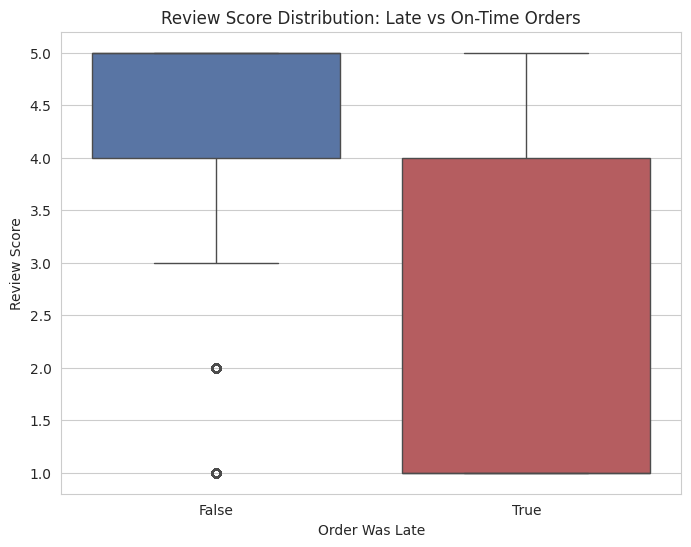

In [112]:
# boxplot: review score distribution for late vs on-time orders
plt.figure(figsize=(8, 6))

sns.boxplot(data=delivered, x="is_late", y="review_score", palette=[color_good, color_bad])

plt.title("Review Score Distribution: Late vs On-Time Orders")
plt.xlabel("Order Was Late")
plt.ylabel("Review Score")
plt.show()

***<font size="5" color='Cyan'>Hypothesis 2: Orders where the seller and customer are in different states take longer to deliver than same-state orders.</font>***

In [78]:
# add customer_state to our delivered orders table
delivered = delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")

print(delivered.shape)
print(delivered["customer_state"].isnull().sum())

(96182, 13)
0


In [79]:
# attach seller_state to each item row, by looking up the seller's state

items_with_seller=items.merge(sellers[["seller_id","seller_state"]],on="seller_id",how="left")

print(items_with_seller.shape)

(112650, 8)


In [80]:
# for each order, find the most common seller_state among its items, and count how many unique sellers were involved

order_seller_info = items_with_seller.groupby("order_id").agg(
    main_seller_state=("seller_state", lambda x: x.mode()[0] if not x.mode().empty else None),
    n_sellers=("seller_id", "nunique")
).reset_index()

print(order_seller_info.shape)

(98666, 3)


In [81]:
order_seller_info.head()

,order_id,main_seller_state,n_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,SP,1
1,00018f77f2f0320c557190d7a144bdd3,SP,1
2,000229ec398224ef6ca0657da4fc703e,MG,1
3,00024acbcdf0a6daa1e931b038114c75,SP,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,PR,1


In [82]:
# add seller state info to our delivered orders table

delivered = delivered.merge(order_seller_info,on="order_id",how="left")

print(delivered.shape)
print(delivered["main_seller_state"].isnull().sum())

(96182, 15)
0


In [83]:
# flag whether seller and customer are in different states(True=diff states,False=Same state)

delivered["cross_state"] = delivered["customer_state"] != delivered["main_seller_state"]

delivered["cross_state"].value_counts()

,count
cross_state,
True,61571
False,34611


In [84]:
delivered.groupby("cross_state")["delivery_days"].mean()

,delivery_days
cross_state,
False,7.386756
True,14.384710


Cross-state orders take almost double the time, roughly 7 extra days on average. This makes intuitive sense too, shipping within the same state is naturally faster than crossing state borders across Brazil's large geography.

In [85]:
# statistical test: is the delivery time difference between cross-state vs same-state orders real, or random chance?

cross_state_days = delivered[delivered["cross_state"] == True]["delivery_days"].dropna()
same_state_days = delivered[delivered["cross_state"] == False]["delivery_days"].dropna()

stat, p_value = stats.mannwhitneyu(cross_state_days, same_state_days, alternative="greater")
print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 1697191652.5
p-value: 0.0


<font color='yellow'>
Cross-state orders (where the seller and customer are in different states) took noticeably longer to deliver than same-state orders (average 14.38 days vs 7.39 days, nearly double). A Mann-Whitney U test confirmed this difference is statistically significant (p < 0.001).

Verdict: Supported.</font>

/tmp/ipykernel_869/3442063691.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivered, x="cross_state", y="delivery_days", palette=[color_good, color_bad])


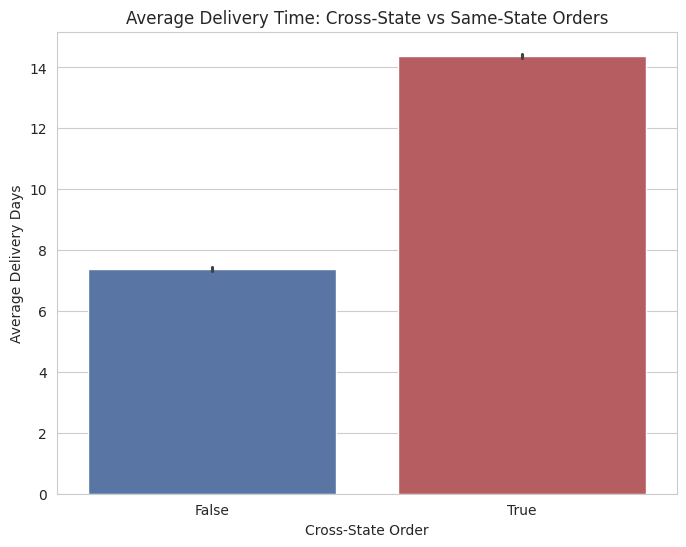

In [113]:
# bar chart: average delivery time, cross-state vs same-state orders
plt.figure(figsize=(8, 6))

sns.barplot(data=delivered, x="cross_state", y="delivery_days", palette=[color_good, color_bad])

plt.title("Average Delivery Time: Cross-State vs Same-State Orders")
plt.xlabel("Cross-State Order")
plt.ylabel("Average Delivery Days")
plt.show()

***<font size="5" color='Cyan'>Hypothesis 3 : A higher freight cost relative to product price is associated with lower review scores.</font>***

In [86]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [87]:
items_order_info = items.groupby("order_id").agg(
    total_price=("price","sum"),
    total_freight=("freight_value","sum")
).reset_index()

print(items_order_info.shape)

(98666, 3)


In [88]:
delivered = delivered.merge(items_order_info,on="order_id",how="left")
print(delivered.shape)
print(delivered["total_price"].isnull().sum())

(96182, 18)
0


In [89]:
delivered["freight_ratio"] = delivered["total_freight"] / delivered["total_price"]

In [90]:
# count orders where total_price is exactly 0 (would break the ratio)
print("Zero prices:", (delivered["total_price"] == 0).sum())

# count infinite values in freight_ratio (happens if price is 0)
print("Infinite values:", np.isinf(delivered["freight_ratio"]).sum())

# count missing values in freight_ratio
print("Missing values:", delivered["freight_ratio"].isnull().sum())

# summary statistics of freight_ratio
delivered["freight_ratio"].describe()

Zero prices: 0
Infinite values: 0
Missing values: 0


,freight_ratio
count,96182.000000
mean,0.308359
std,0.311465
min,0.000000
25%,0.132017
50%,0.224374
75%,0.380531
max,21.447059


## Spearman correlation test

In [91]:
# keep only the two columns needed for H3, and drop rows with a missing review_score
h3_data = delivered[["freight_ratio", "review_score"]].dropna()

# Spearman correlation: do freight_ratio and review_score move in opposite directions?
# corr and p_value are variable names we chose; stats.spearmanr() is the actual test function
corr, p_value = stats.spearmanr(h3_data["freight_ratio"], h3_data["review_score"], alternative="less")

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: -0.030930322186471217
p-value: 5.71212143310671e-22


<font color='yellow'>
A Spearman correlation test found a statistically significant negative relationship between freight ratio and review score (rho = -0.031, p < 0.001), so orders with higher shipping cost relative to price tend to receive slightly lower reviews. However, the effect is negligible in size, which means freight cost alone is not a meaningful driver of customer satisfaction in this dataset.

Verdict: Weakly supported (statistically significant, but a negligible effect).
</font>


/tmp/ipykernel_869/3846461699.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freight_bin_scores = delivered.groupby("freight_ratio_bin")["review_score"].mean()


freight_ratio_bin
0-0.2      4.190842
0.2-0.4    4.150259
0.4-0.6    4.129701
0.6-1.0    4.128462
1.0+       4.043693
Name: review_score, dtype: float64


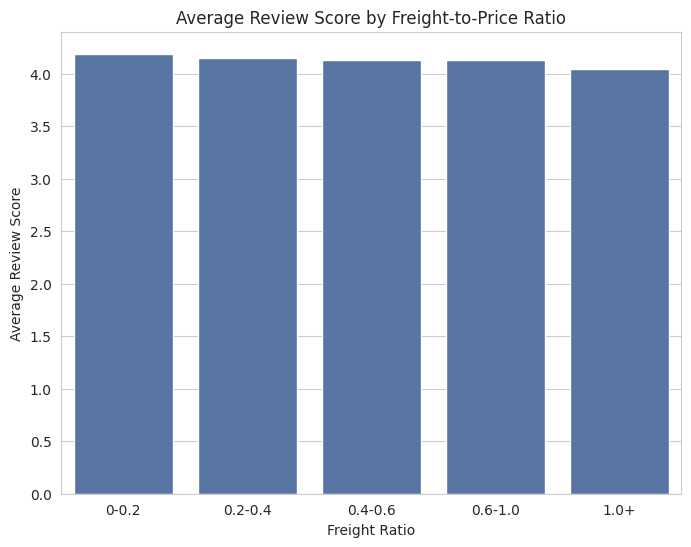

In [114]:
# split freight_ratio into readable bins
delivered["freight_ratio_bin"] = pd.cut(
    delivered["freight_ratio"],
    bins=[0, 0.2, 0.4, 0.6, 1.0, float("inf")],
    labels=["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-1.0", "1.0+"]
)

# average review score per freight ratio bin
freight_bin_scores = delivered.groupby("freight_ratio_bin")["review_score"].mean()
print(freight_bin_scores)

# bar chart: average review score by freight ratio bin
plt.figure(figsize=(8, 6))
sns.barplot(x=freight_bin_scores.index, y=freight_bin_scores.values, color=color_good)

plt.title("Average Review Score by Freight-to-Price Ratio")
plt.xlabel("Freight Ratio")
plt.ylabel("Average Review Score")
plt.show()

***<font size="5" color='Cyan'>Hypothesis 4a : ate delivery rates differ significantly across Brazilian states.</font>***

In [96]:
del_rate_state = delivered.groupby("customer_state")["is_late"].mean().sort_values(ascending=False)
print(del_rate_state)

customer_state
AL    0.208122
MA    0.169944
SE    0.144578
PI    0.131356
CE    0.124006
RJ    0.114600
BA    0.114277
ES    0.103223
PA    0.101604
TO    0.098540
PB    0.097466
MS    0.097004
PE    0.090909
RN    0.085106
SC    0.080791
GO    0.063492
RS    0.059231
MT    0.056625
DF    0.056277
RR    0.052632
MG    0.044954
SP    0.043693
PR    0.039252
RO    0.028807
AM    0.020833
AP    0.015152
AC    0.012821
Name: is_late, dtype: float64


In [97]:
delivered["customer_state"].value_counts()

,count
customer_state,
SP,40441
RJ,12260
MG,11345
RS,5335
PR,4917
SC,3540
BA,3229
DF,2079
ES,1986


# Chi-square test

In [98]:
# build a table of counts: each state's orders, split by late vs on-time

state_late_table = pd.crosstab(delivered["customer_state"], delivered["is_late"])
print(state_late_table)

is_late         False  True 
customer_state              
AC                 77      1
AL                312     82
AM                141      3
AP                 65      1
BA               2860    369
CE               1102    156
DF               1962    117
ES               1781    205
GO               1829    124
MA                591    121
MG              10835    510
MS                633     68
MT                833     50
PA                840     95
PB                463     50
PE               1440    144
PI                410     62
PR               4724    193
RJ              10855   1405
RN                430     40
RO                236      7
RR                 36      2
RS               5019    316
SC               3254    286
SE                284     48
SP              38674   1767
TO                247     27


In [99]:
# chi-square test: is lateness related to state, or independent of it?
chi2, p_value, dof, expected = stats.chi2_contingency(state_late_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1611.4443974482112
p-value: 0.0
Degrees of freedom: 26


<font color='yellow'>
A chi-square test confirmed that late delivery rates differ significantly by state (χ² = 1611.4, p < 0.001). Northeastern states such as Alagoas (20.8%) and Maranhão (17.0%) had the highest late rates, while São Paulo (4.4%), the main hub for sellers, had one of the lowest. This pattern aligns with Hypothesis 2's finding that cross-state orders take longer to deliver, suggesting that distance from major seller hubs is a key driver of late deliveries.

Verdict: Supported.
</font>

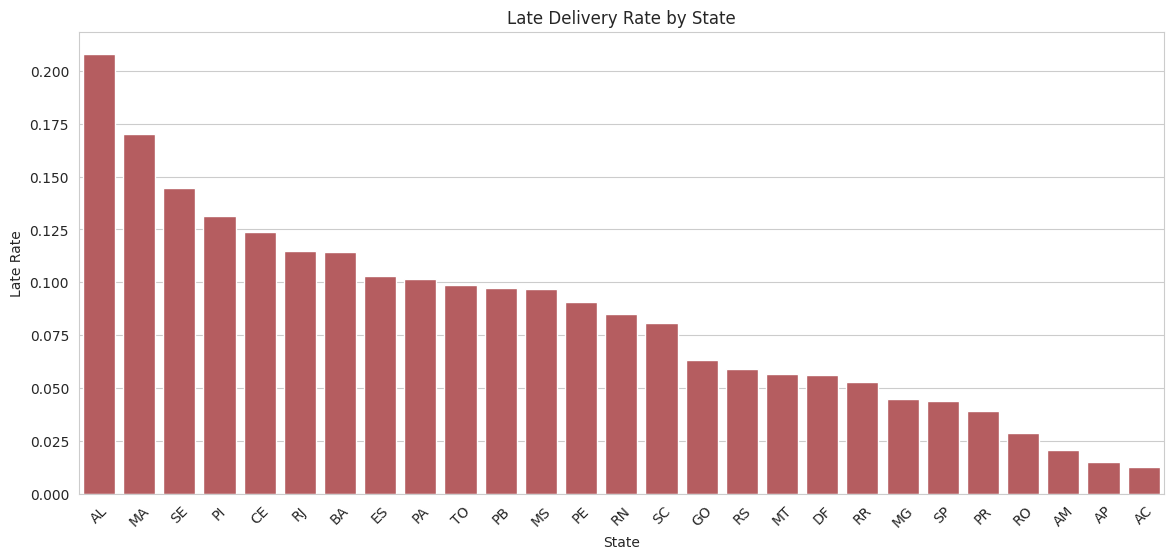

In [115]:
# bar chart: late delivery rate by state, sorted highest to lowest
plt.figure(figsize=(14, 6))

sns.barplot(x=del_rate_state.index, y=del_rate_state.values, color=color_bad)

plt.title("Late Delivery Rate by State")
plt.xlabel("State")
plt.ylabel("Late Rate")
plt.xticks(rotation=45)
plt.show()

***<font size="5" color='Cyan'>Hypothesis 4b : Late delivery rates are higher during peak demand months, such as November.</font>***

In [100]:
# pull the purchase year out of the order date
delivered["purchase_year"] = delivered["order_purchase_timestamp"].dt.year

print(delivered["purchase_year"].value_counts())

purchase_year
2018    52624
2017    43294
2016      264
Name: count, dtype: int64


In [101]:
# keep only 2017 and 2018 orders, since 2016 is too small a sample (only 264 orders)
delivered_recent = delivered[delivered["purchase_year"].isin([2017, 2018])].copy()

# pull the purchase month out of the order date
delivered_recent["purchase_month"] = delivered_recent["order_purchase_timestamp"].dt.month

# late rate per month
month_late_rate = delivered_recent.groupby("purchase_month")["is_late"].mean().sort_values(ascending=False)
print(month_late_rate)

purchase_month
3     0.146573
11    0.120782
2     0.112515
12    0.070687
5     0.052043
1     0.049737
8     0.048662
4     0.047493
9     0.042240
10    0.040259
7     0.030158
6     0.016278
Name: is_late, dtype: float64


In [102]:
# build a table of counts: each month's orders, split by late vs on-time
month_late_table = pd.crosstab(delivered_recent["purchase_month"], delivered_recent["is_late"])

# chi-square test: is lateness related to month, or independent of it?
chi2, p_value, dof, expected = stats.chi2_contingency(month_late_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 2503.2094325718235
p-value: 0.0
Degrees of freedom: 11


<font color='yellow'>
A chi-square test confirmed that late delivery rates differ significantly by month (χ² = 2503.2, p < 0.001). November did show an elevated late rate (12.1%), the second-highest of the year, consistent with increased order volume around Black Friday. However, March had the highest late rate overall (14.7%), suggesting that factors beyond the Black Friday shopping surge, which Olist may already prepare logistics capacity for, also affect delivery reliability in certain months.

Verdict: Partially supported. Month has a significant effect on late delivery rates, but November is not the single worst-performing month.
</font>

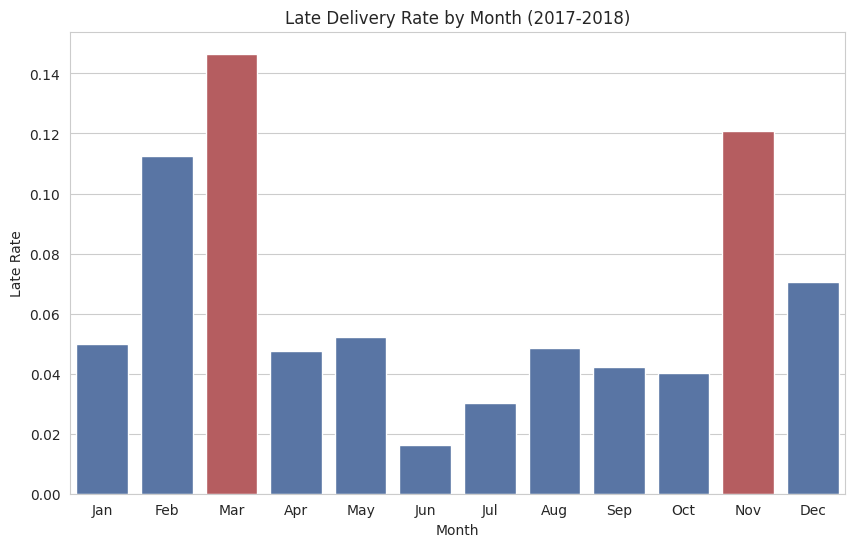

In [117]:
# order months calendar-wise (not sorted by rate), and prepare colors
month_order = list(range(1, 13))
month_rates_ordered = month_late_rate.reindex(month_order)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# highlight March and November specifically, rest in neutral color
bar_colors = [color_bad if m in [3, 11] else color_good for m in month_order]

plt.figure(figsize=(10, 6))
sns.barplot(x=month_names, y=month_rates_ordered.values, hue=month_names, palette=bar_colors, legend=False)

plt.title("Late Delivery Rate by Month (2017-2018)")
plt.xlabel("Month")
plt.ylabel("Late Rate")
plt.show()

***<font size="5" color='Cyan'>Hypothesis 5 : Customers whose first order arrives late are less likely to place a second order than customers whose first order arrives on time.</font>***

In [103]:
# add customer_unique_id to our delivered orders table (tracks the same person across orders)
delivered = delivered.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

print(delivered.shape)
print(delivered["customer_unique_id"].isnull().sum())

(96182, 21)
0


In [104]:
first_orders = delivered.sort_values("order_purchase_timestamp").drop_duplicates(subset="customer_unique_id", keep="first")
print(first_orders.shape)

(93071, 21)


In [105]:
# count how many orders each customer placed in total
customer_order_counts = delivered.groupby("customer_unique_id")["order_id"].count().reset_index()
customer_order_counts.columns = ["customer_unique_id", "total_orders"]

print(customer_order_counts.shape)
print(customer_order_counts["total_orders"].value_counts())

(93071, 2)
total_orders
1     90278
2      2566
3       180
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


In [106]:
# combine each customer's first-order lateness with their total order count
customer_summary = first_orders[["customer_unique_id", "is_late"]].merge(
    customer_order_counts, on="customer_unique_id", how="left"
)

# flag customers who placed more than one order
customer_summary["is_repeat_customer"] = customer_summary["total_orders"] > 1

print(customer_summary.shape)
customer_summary.head()

(93071, 4)


,customer_unique_id,is_late,total_orders,is_repeat_customer
0,830d5b7aaa3b6f1e9ad63703bec97d23,True,1,False
1,32ea3bdedab835c3aa6cb68ce66565ef,False,3,True
2,2f64e403852e6893ae37485d5fcacdaf,False,1,False
3,61db744d2f835035a5625b59350c6b63,False,1,False
4,8d3a54507421dbd2ce0a1d58046826e0,False,1,False


In [107]:
# compare repeat purchase rate: customers whose first order was late vs on-time
customer_summary.groupby("is_late")["is_repeat_customer"].mean()

,is_repeat_customer
is_late,
False,0.030324
True,0.025506


In [108]:
# build a table of counts: late vs on-time first order, split by repeat vs one-time customer
late_repeat_table = pd.crosstab(customer_summary["is_late"], customer_summary["is_repeat_customer"])
print(late_repeat_table)

# chi-square test: is repeat purchase behavior related to whether the first order was late?
chi2, p_value, dof, expected = stats.chi2_contingency(late_repeat_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

is_repeat_customer  False  True 
is_late                         
False               84356   2638
True                 5922    155
Chi-square statistic: 4.365598760002124
p-value: 0.03667159348494767
Degrees of freedom: 1


<font color='yellow'>
Customers whose first order arrived late had a slightly lower repeat purchase rate (2.55%) than customers whose first order was on time (3.03%). A chi-square test found this difference to be statistically significant, though only marginally (χ² = 4.37, p = 0.037). Given the small effect size and borderline significance, this result should be interpreted cautiously, delivery lateness on a single order does not appear to be a strong standalone driver of customer churn in this dataset, though it may contribute alongside other factors.

Verdict: Weakly supported (borderline significance, small effect).
</font>

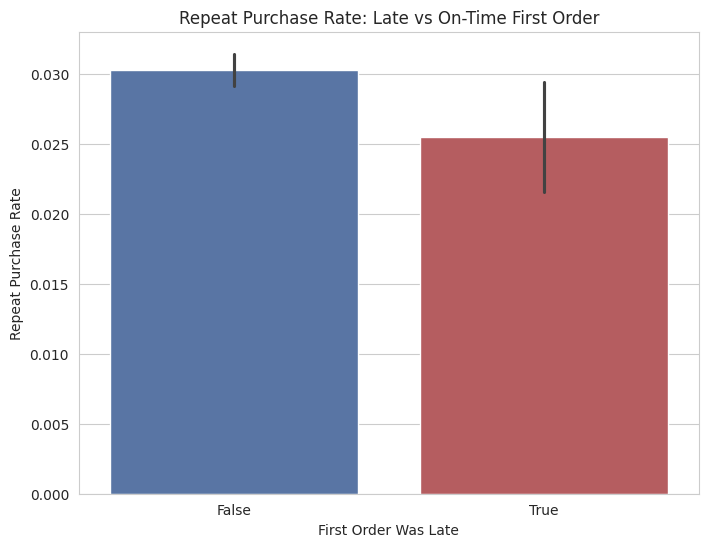

In [119]:
# bar chart: repeat purchase rate, late vs on-time first order
plt.figure(figsize=(8, 6))

sns.barplot(data=customer_summary, x="is_late", y="is_repeat_customer", hue="is_late", palette=[color_good, color_bad], legend=False)

plt.title("Repeat Purchase Rate: Late vs On-Time First Order")
plt.xlabel("First Order Was Late")
plt.ylabel("Repeat Purchase Rate")
plt.show()

***<font size="5" color='cyan'> Seller and Category Performance: Where Are Late Deliveries Concentrated? </font>***

In [120]:
# bring order-level is_late into the item-level table (connects seller info with lateness)
items_with_late = items_with_seller.merge(delivered[["order_id", "is_late"]], on="order_id", how="left")

print(items_with_late.shape)
print(items_with_late["is_late"].isnull().sum())

(112650, 9)
2772


In [121]:
# drop items whose order wasn't in our cleaned delivered dataset
items_with_late_clean = items_with_late.dropna(subset=["is_late"])

# calculate late rate and item count per seller
seller_performance = items_with_late_clean.groupby("seller_id").agg(
    late_rate=("is_late", "mean"),
    n_items=("is_late", "count")
).reset_index()

print(seller_performance.shape)
seller_performance.head()

(2967, 3)


,seller_id,late_rate,n_items
0,0015a82c2db000af6aaaf3ae2ecb0532,0.0,3
1,001cca7ae9ae17fb1caed9dfb1094831,0.043103,232
2,002100f778ceb8431b7a1020ff7ab48f,0.166667,54
3,003554e2dce176b5555353e4f3555ac8,0.0,1
4,004c9cd9d87a3c30c522c48c4fc07416,0.053892,167


In [122]:
# keep only sellers with enough volume to trust their late rate (20+ items)
seller_performance_reliable = seller_performance[seller_performance["n_items"] >= 20]

# sort to find the worst-performing sellers
worst_sellers = seller_performance_reliable.sort_values("late_rate", ascending=False)

print(worst_sellers.shape)
worst_sellers.head(10)

(880, 3)


,seller_id,late_rate,n_items
451,2709af9587499e95e803a6498a5a56e9,0.5,46
1542,821fb029fc6e495ca4f08a35d51e53a5,0.32,25
2763,ede0c03645598cdfc63ca8237acbe73d,0.319149,47
2009,ad781527c93d00d89a11eecd9dcad7c1,0.297297,37
1000,54965bbe3e4f07ae045b90b0b8541f52,0.294872,78
2870,f76a3b1349b6df1ee875d1f3fa4340f0,0.291667,24
533,2e1a7d075abe038c1b2743005fe42ff1,0.272727,22
1555,835f0f7810c76831d6c7d24c7a646d4d,0.270833,48
57,054694fa03fe82cec4b7551487331d74,0.25,20
1332,71039d19d4303bf9054d69e9a9236699,0.236842,38


<font color='yellow'> Additional Analysis: Seller Performance

Among sellers with at least 20 items sold (880 sellers), late delivery rates varied widely. The worst-performing seller had a 50% late rate across 46 items, nearly 8 times the platform-wide average of 6.5%. The 10 worst sellers all exceeded a 23% late rate. This suggests that a small number of consistently underperforming sellers may be disproportionately responsible for poor delivery outcomes, and could be targeted directly for review or improvement, rather than Olist needing to address delivery policy platform-wide.</font>